<a href="https://colab.research.google.com/github/yash6871/EDA/blob/main/Titanic1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
import numpy as np
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt

In [5]:
data=sns.load_dataset('titanic')

In [6]:
data.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [7]:
data.shape

(891, 15)

In [8]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        891 non-null    object  
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), object(5)
memory usage: 80.7+ KB


In [9]:
data['survived'].value_counts()

,count
survived,
0,549
1,342


In [10]:
data['sex'].value_counts()

,count
sex,
male,577
female,314


<Axes: xlabel='sex', ylabel='count'>

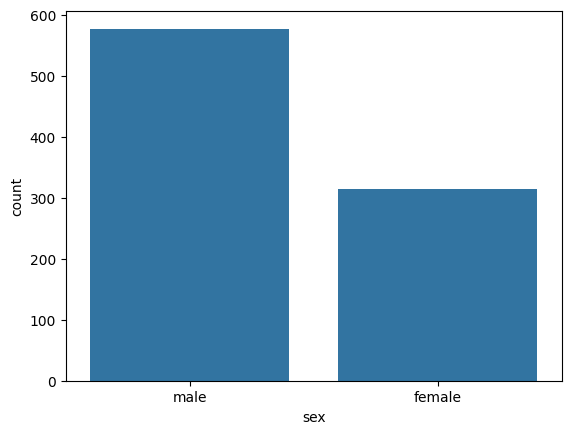

In [11]:
sns.countplot(x='sex',data=data)

<Axes: xlabel='sex', ylabel='count'>

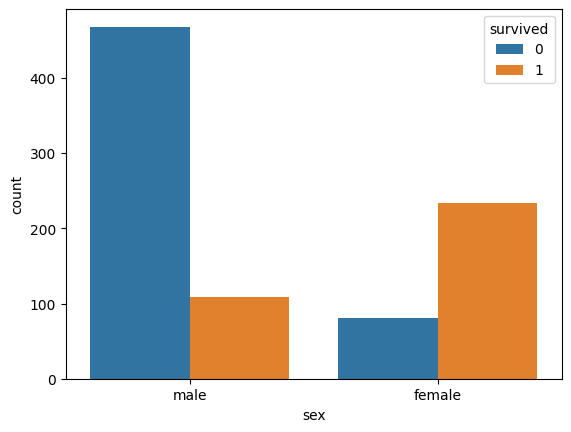

In [12]:
sns.countplot(x='sex',hue='survived',data=data)

In [13]:
data.isnull().sum()

,0
survived,0
pclass,0
sex,0
age,177
sibsp,0
parch,0
fare,0
embarked,2
class,0
who,0


In [14]:
data.isnull().sum().idxmax()

'deck'

In [15]:
data.drop(columns='deck',inplace=True)

In [16]:
data.sample()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,embark_town,alive,alone
677,1,3,female,18.0,0,0,9.8417,S,Third,woman,False,Southampton,yes,True


In [17]:
data['age'].fillna(data['age'].median(),inplace=True)

/tmp/ipykernel_635/3768969743.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data['age'].fillna(data['age'].median(),inplace=True)


In [18]:
data['age'].isnull().sum()

np.int64(0)

<Axes: xlabel='pclass', ylabel='count'>

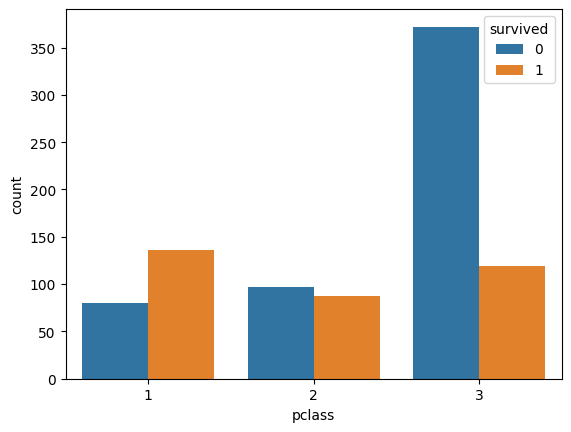

In [19]:
sns.countplot(x='pclass',hue='survived',data=data)

<Axes: xlabel='age', ylabel='Count'>

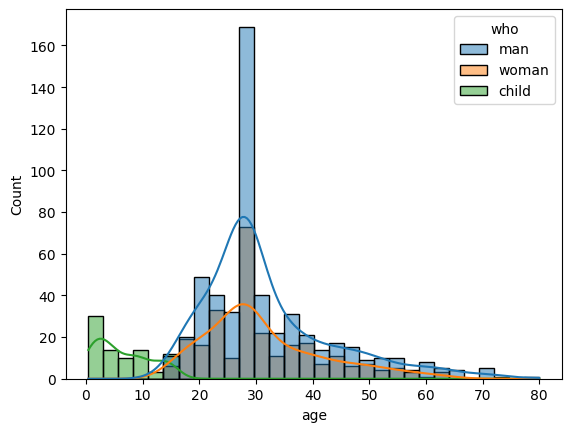

In [20]:
sns.histplot(x='age',data=data,kde=True,hue='who')

<Axes: xlabel='survived', ylabel='age'>

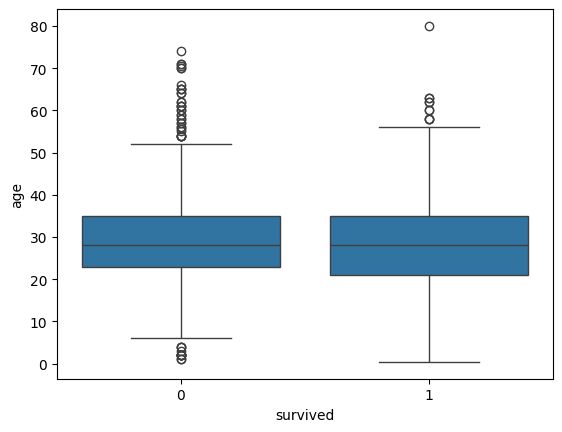

In [21]:
sns.boxplot(x='survived',y='age',data=data)

<Axes: xlabel='sex', ylabel='survived'>

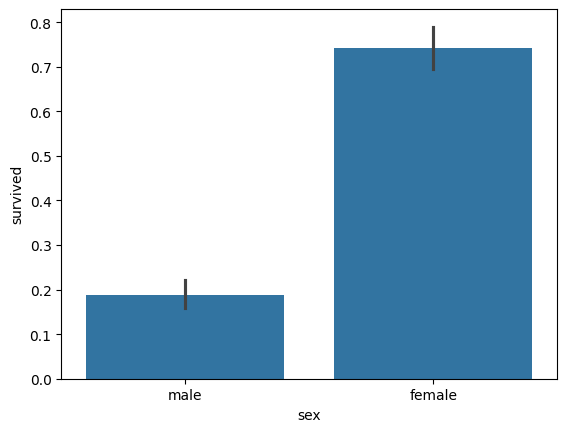

In [22]:
sns.barplot(x='sex',y='survived',data=data)

In [23]:
data.groupby(['pclass','sex'])['survived'].mean()

pclass  sex   
1       female    0.968085
        male      0.368852
2       female    0.921053
        male      0.157407
3       female    0.500000
        male      0.135447
Name: survived, dtype: float64

<Axes: xlabel='pclass', ylabel='survived'>

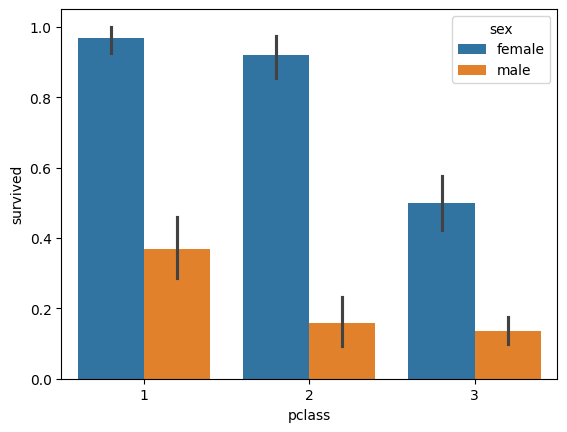

In [24]:
sns.barplot(x='pclass',y='survived',data=data,hue='sex')

In [25]:
data.corr(numeric_only=True)

,survived,pclass,age,sibsp,parch,fare,adult_male,alone
survived,1.000000,-0.338481,-0.064910,-0.035322,0.081629,0.257307,-0.557080,-0.203367
pclass,-0.338481,1.000000,-0.339898,0.083081,0.018443,-0.549500,0.094035,0.135207
age,-0.064910,-0.339898,1.000000,-0.233296,-0.172482,0.096688,0.247704,0.171647
sibsp,-0.035322,0.083081,-0.233296,1.000000,0.414838,0.159651,-0.253586,-0.584471
parch,0.081629,0.018443,-0.172482,0.414838,1.000000,0.216225,-0.349943,-0.583398
fare,0.257307,-0.549500,0.096688,0.159651,0.216225,1.000000,-0.182024,-0.271832
adult_male,-0.557080,0.094035,0.247704,-0.253586,-0.349943,-0.182024,1.000000,0.404744
alone,-0.203367,0.135207,0.171647,-0.584471,-0.583398,-0.271832,0.404744,1.000000


<Axes: >

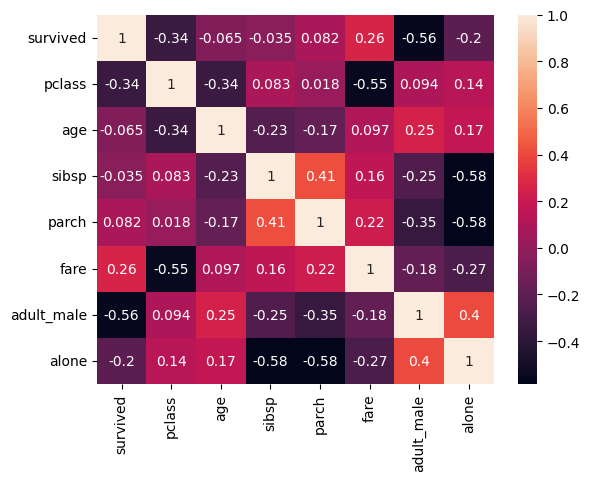

In [26]:
sns.heatmap(data.corr(numeric_only=True),annot=True)

<Axes: xlabel='fare'>

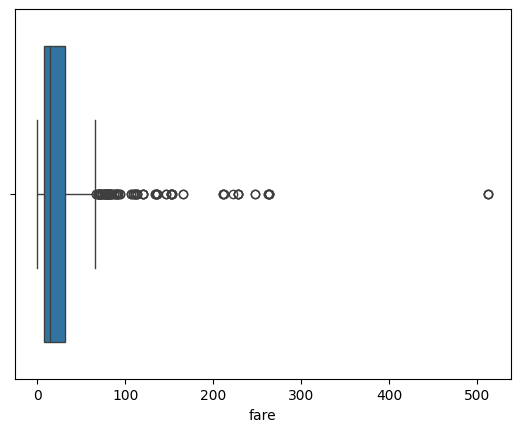

In [27]:
sns.boxplot(x='fare',data=data)

In [28]:
data['family_size']=data['sibsp']+data['parch']

<Axes: xlabel='family_size', ylabel='count'>

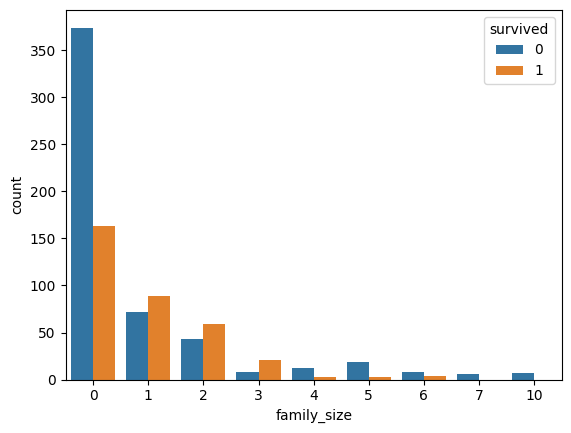

In [29]:
sns.countplot(x='family_size',data=data,hue='survived')

In [30]:
pd.crosstab(data['sex'], data['survived'])

survived,0,1
sex,,
female,81,233
male,468,109


In [31]:
pd.crosstab(data['sex'],data['survived'],normalize='index')

survived,0,1
sex,,
female,0.257962,0.742038
male,0.811092,0.188908


In [33]:
data.pivot_table(index='pclass',aggfunc='mean',values='fare')

,fare
pclass,
1,84.154687
2,20.662183
3,13.675550


<Axes: xlabel='pclass', ylabel='fare'>

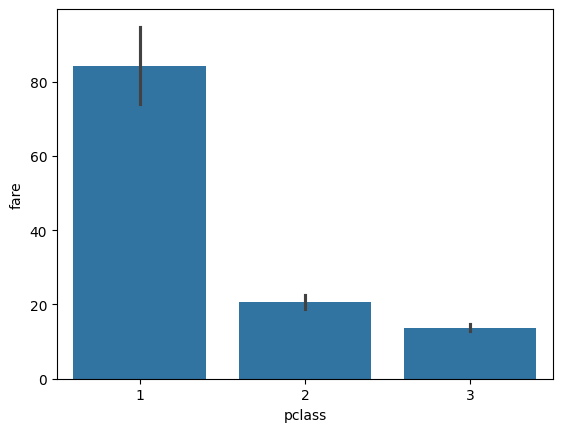

In [34]:
sns.barplot(x='pclass',y='fare',data=data)

In [35]:
data['age_group']=pd.cut(data['age'],bins=[0,12,19,59,100],labels=['child','teen','adult','senior'])

In [36]:
data

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,embark_town,alive,alone,family_size,age_group
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,Southampton,no,False,1,adult
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,Cherbourg,yes,False,1,adult
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,Southampton,yes,True,0,adult
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,Southampton,yes,False,1,adult
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,Southampton,no,True,0,adult
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,0,2,male,27.0,0,0,13.0000,S,Second,man,True,Southampton,no,True,0,adult
887,1,1,female,19.0,0,0,30.0000,S,First,woman,False,Southampton,yes,True,0,teen
888,0,3,female,28.0,1,2,23.4500,S,Third,woman,False,Southampton,no,False,3,adult
889,1,1,male,26.0,0,0,30.0000,C,First,man,True,Cherbourg,yes,True,0,adult


<Axes: xlabel='age_group', ylabel='count'>

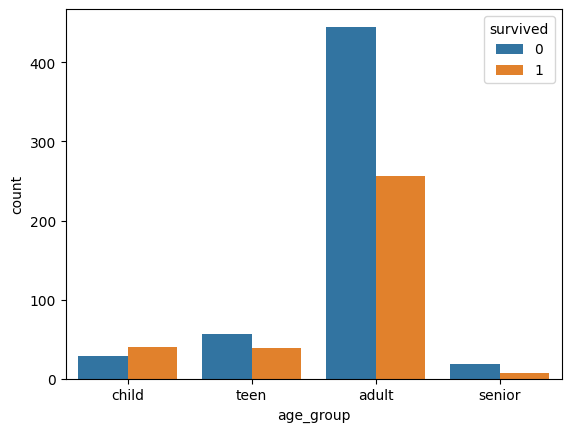

In [37]:
sns.countplot(x='age_group',hue='survived',data=data)

In [38]:
data["travel_type"]=np.where(data['family_size']==0,'Alone','Family')

In [39]:
data.sample()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,embark_town,alive,alone,family_size,age_group,travel_type
265,0,2,male,36.0,0,0,10.5,S,Second,man,True,Southampton,no,True,0,adult,Alone


<Axes: xlabel='travel_type', ylabel='count'>

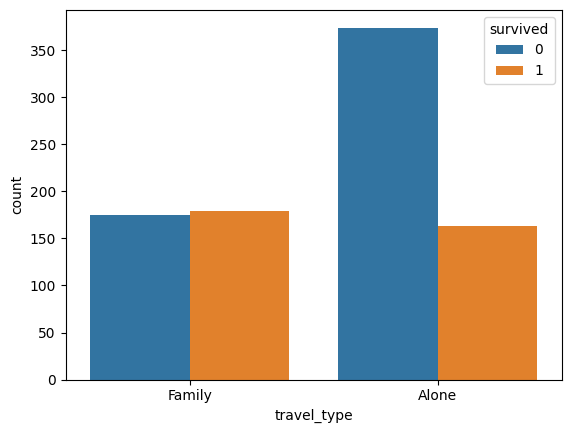

In [42]:
sns.countplot(x='travel_type',hue='survived',data=data)

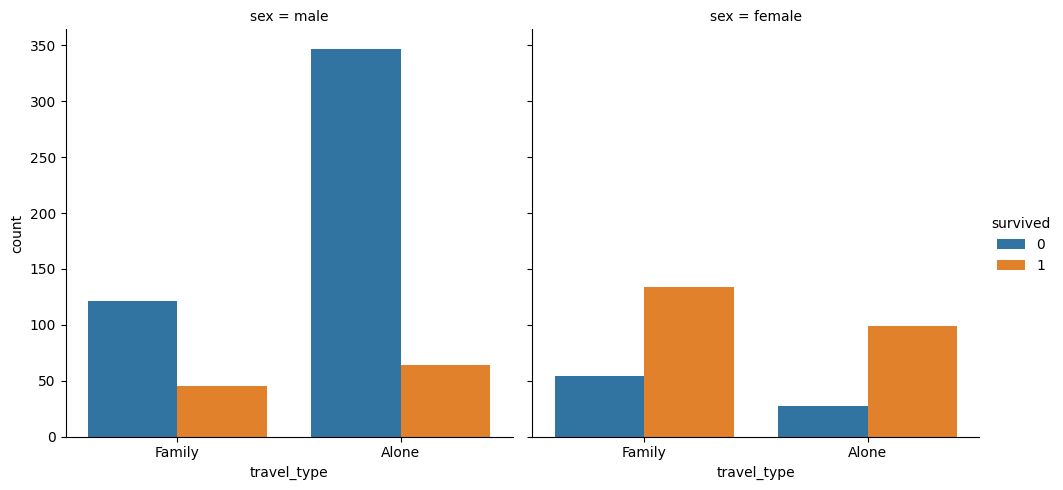

In [43]:
sns.catplot(x='travel_type', hue='survived', col='sex', data=data, kind='count')

<Axes: xlabel='pclass', ylabel='fare'>

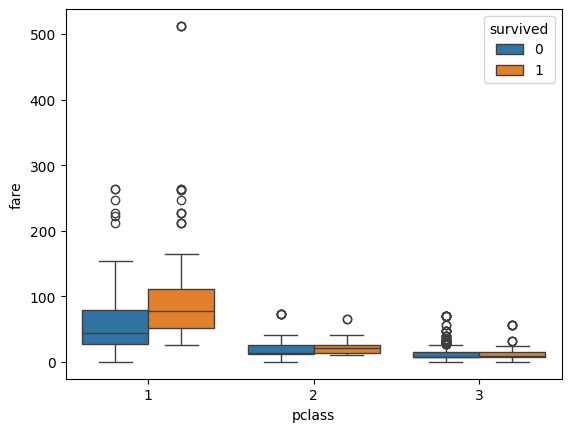

In [44]:
sns.boxplot(x='pclass',y='fare',hue='survived',data=data)